In [1]:
import pandas as pd
import SimpleITK as sitk
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
import ast

In [ ]:
df_pre_data = pd.read_csv(r'preprocessing_log.csv')

In [17]:
df_pre_data[df_pre_data['status']=='Failed'].to_csv('failed_preprocessing_temp.csv', index=False)

In [10]:
df_pre_data.dtypes

SeriesInstanceUID    object
status               object
shape_z_y_x          object
error                object
dtype: object

In [26]:
df_pre_data_suc = df_pre_data[df_pre_data['status']=='Success'].copy()

In [19]:
df_pre_data_suc.shape

(1794, 4)

In [20]:
df_pre_data_suc

,SeriesInstanceUID,status,shape_z_y_x,error
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,Success,"(86, 299, 253)",NaN
1,1.2.826.0.1.3680043.8.498.10014757658335054766...,Success,"(163, 297, 234)",NaN
2,1.2.826.0.1.3680043.8.498.10021411248005513321...,Success,"(124, 314, 240)",NaN
3,1.2.826.0.1.3680043.8.498.10022796280698534221...,Success,"(8, 45, 65)",NaN
4,1.2.826.0.1.3680043.8.498.10030095840917973694...,Success,"(106, 174, 240)",NaN
...,...,...,...,...
1852,1.2.826.0.1.3680043.8.498.99887675554378211308...,Success,"(44, 153, 58)",NaN
1853,1.2.826.0.1.3680043.8.498.99892390884723813599...,Success,"(128, 305, 251)",NaN
1854,1.2.826.0.1.3680043.8.498.99895756899933461331...,Success,"(25, 62, 58)",NaN
1855,1.2.826.0.1.3680043.8.498.99953513260518059135...,Success,"(18, 117, 75)",NaN


In [ ]:
df_pre_data_suc['shape_z_y_x'] = df_pre_data_suc['shape_z_y_x'].apply(ast.literal_eval)

In [ ]:
def find_area(x):
    x,y,z= x
    return x*y*z

In [ ]:
df_pre_data_suc['area'] = df_pre_data_suc['shape_z_y_x'].apply(find_area)

<Axes: xlabel='area'>

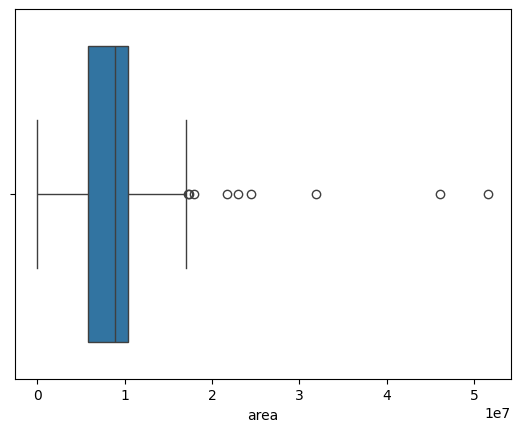

In [45]:
sns.boxplot(x=df_pre_data_suc['area'])

In [5]:
list_of_files = os.listdir(r'processed_data')

In [7]:
train_df = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train.csv')

In [9]:
train_df

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.10004044428023505108...,64,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1.2.826.0.1.3680043.8.498.10004684224894397679...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1.2.826.0.1.3680043.8.498.10005158603912009425...,58,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,1.2.826.0.1.3680043.8.498.10009383108068795488...,71,Male,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1.2.826.0.1.3680043.8.498.10012790035410518400...,48,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4400,1.2.826.0.1.3680043.8.498.99915610493694667606...,62,Female,MRI T1post,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4401,1.2.826.0.1.3680043.8.498.99920680741054836990...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4402,1.2.826.0.1.3680043.8.498.99953513260518059135...,44,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4403,1.2.826.0.1.3680043.8.498.99982144859397209076...,58,Female,MRI T2,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [35]:
prep_df = pd.DataFrame((files[:-7] for files in list_of_files), columns=['SeriesInstanceUID'])
prep_df.iloc[3].values


array(['1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557'],
      dtype=object)

In [36]:
prep_df = prep_df.merge(train_df, how='inner', on='SeriesInstanceUID')
prep_df


,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,58,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,1,1
1,1.2.826.0.1.3680043.8.498.10014757658335054766...,53,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1.2.826.0.1.3680043.8.498.10021411248005513321...,55,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1.2.826.0.1.3680043.8.498.10034081836061566510...,54,Male,CTA,0,0,0,0,0,0,1,0,0,0,0,0,0,1
4,1.2.826.0.1.3680043.8.498.10035643165968342618...,62,Female,CTA,0,0,0,1,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,1.2.826.0.1.3680043.8.498.99344977894147397154...,66,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
660,1.2.826.0.1.3680043.8.498.99437700549224405450...,53,Female,CTA,0,0,0,0,0,0,0,1,0,0,0,0,0,1
661,1.2.826.0.1.3680043.8.498.99892390884723813599...,68,Female,CTA,0,0,0,0,1,1,0,0,0,0,0,0,0,1
662,1.2.826.0.1.3680043.8.498.99895756899933461331...,39,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [37]:
list_seg = os.listdir(r'rsna-intracranial-aneurysm-detection\segmentations')

In [38]:
list_seg

['1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381',
 '1.2.826.0.1.3680043.8.498.10076056930521523789588901704956188485',
 '1.2.826.0.1.3680043.8.498.10188636688783982623025997809119805350',
 '1.2.826.0.1.3680043.8.498.10410600166004340343973545138447283460',
 '1.2.826.0.1.3680043.8.498.10540586847553109495238524904638776495',
 '1.2.826.0.1.3680043.8.498.10557880026294057874761753231388788828',
 '1.2.826.0.1.3680043.8.498.10759842474698331813589731619457567641',
 '1.2.826.0.1.3680043.8.498.10838261583340080792086755879475952843',
 '1.2.826.0.1.3680043.8.498.10865391592895615633871689438787039175',
 '1.2.826.0.1.3680043.8.498.10929608782694347957516071062422315982',
 '1.2.826.0.1.3680043.8.498.10935907012185032169927418164924236382',
 '1.2.826.0.1.3680043.8.498.11140496970152788589837488009637704168',
 '1.2.826.0.1.3680043.8.498.11163718560814217911019576488539324434',
 '1.2.826.0.1.3680043.8.498.11365717786702723641614356829695498020',
 '1.2.826.0.1.3680043.8.498.114229

In [52]:
from view3d_data import *
from preprocess_ct import *

In [55]:
seg_mask = sitk.ReadImage(str(r'rsna-intracranial-aneurysm-detection\segmentations\1.2.826.0.1.3680043.8.498.10076056930521523789588901704956188485\1.2.826.0.1.3680043.8.498.10076056930521523789588901704956188485.nii'))

In [56]:
seg_mask_np = sitk.GetArrayFromImage(seg_mask)
seg_mask_np.shape

(136, 1024, 1024)

In [57]:
view_3d_volume(seg_mask_np)

interactive(children=(IntSlider(value=68, description='slice_index', max=135), FloatSlider(value=0.0, descript…

In [54]:
import numpy as np

print("Unique values in mask:", np.unique(seg_mask_np))
print("Number of aneurysm voxels:", np.sum(seg_mask_np > 0))


Unique values in mask: [-1024. -1023. -1022. ...  2680.  2686.  2692.]
Number of aneurysm voxels: 13658632


In [50]:
train_df[train_df['SeriesInstanceUID']=='1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381']

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
13,1.2.826.0.1.3680043.8.498.10035643165968342618...,62,Female,CTA,0,0,0,1,1,0,0,0,1,0,0,0,0,1


In [58]:
local_df = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train_localizers.csv')
local_df

,SeriesInstanceUID,SOPInstanceUID,coordinates,location
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,1.2.826.0.1.3680043.8.498.10775329348174902199...,"{'x': 258.3621186176837, 'y': 261.359900373599}",Other Posterior Circulation
1,1.2.826.0.1.3680043.8.498.10022796280698534221...,1.2.826.0.1.3680043.8.498.53868409774237283281...,"{'x': 194.87253141831238, 'y': 178.32675044883...",Right Middle Cerebral Artery
2,1.2.826.0.1.3680043.8.498.10023411164590664678...,1.2.826.0.1.3680043.8.498.24186535344744886473...,"{'x': 189.23979878597123, 'y': 209.19184886465...",Right Middle Cerebral Artery
3,1.2.826.0.1.3680043.8.498.10030095840917973694...,1.2.826.0.1.3680043.8.498.75217084841854214544...,"{'x': 208.2805049088359, 'y': 229.78962131837307}",Right Infraclinoid Internal Carotid Artery
4,1.2.826.0.1.3680043.8.498.10034081836061566510...,1.2.826.0.1.3680043.8.498.71237104731452368587...,"{'x': 249.86745590416498, 'y': 220.623044646393}",Anterior Communicating Artery
...,...,...,...,...
2281,1.2.826.0.1.3680043.8.498.99892390884723813599...,1.2.826.0.1.3680043.8.498.12398549862508001109...,"{'x': 139.11888111888112, 'y': 283.97202797202...",Right Middle Cerebral Artery
2282,1.2.826.0.1.3680043.8.498.99892390884723813599...,1.2.826.0.1.3680043.8.498.12398549862508001109...,"{'x': 63.132075471698116, 'y': 195.8238993710692}",Left Middle Cerebral Artery
2283,1.2.826.0.1.3680043.8.498.99892390884723813599...,1.2.826.0.1.3680043.8.498.21598979799967012280...,"{'x': 14.510769230769231, 'y': 247.53230769230...",Right Middle Cerebral Artery
2284,1.2.826.0.1.3680043.8.498.99892390884723813599...,1.2.826.0.1.3680043.8.498.21598979799967012280...,"{'x': 167.3230769230769, 'y': 265.64923076923077}",Left Middle Cerebral Artery


In [2]:
import pandas as pd
df_new_logs = pd.read_csv(r'processed_data_v2\preprocessing_log.csv')
df_new_logs  = df_new_logs[df_new_logs['status']!='Skipped']
df_new_logs

,SeriesInstanceUID,status,shape_z_y_x,error
6,1.2.826.0.1.3680043.8.498.10035643165968342618...,Success,"(133, 349, 295)",NaN
11,1.2.826.0.1.3680043.8.498.10077108087009955586...,Success,"(167, 250, 394)",NaN
27,1.2.826.0.1.3680043.8.498.10192011262895867728...,Failed,NaN,need at least one array to stack
36,1.2.826.0.1.3680043.8.498.10291305271924252800...,Failed,NaN,need at least one array to stack
37,1.2.826.0.1.3680043.8.498.10311178483256099259...,Success,"(8, 135, 69)",NaN
...,...,...,...,...
1847,1.2.826.0.1.3680043.8.498.99614492920407247894...,Success,"(178, 346, 272)",NaN
1848,1.2.826.0.1.3680043.8.498.99639493469775227910...,Success,"(98, 325, 290)",NaN
1849,1.2.826.0.1.3680043.8.498.99674090910456004499...,Success,"(143, 348, 266)",NaN
1852,1.2.826.0.1.3680043.8.498.99887675554378211308...,Success,"(81, 231, 231)",NaN


In [3]:
df_new_logs.to_csv(r'processed_data_v2\preprocessing_log.csv', index=False)

In [5]:
df_new_logs = pd.read_csv(r'processed_data_v2\preprocessing_log.csv')
df_o_logs = pd.read_csv(r'processed_data_v2\preprocessing_log_1.csv')

In [13]:
df_o_logs = df_o_logs[~df_o_logs['SeriesInstanceUID'].isin(df_new_logs['SeriesInstanceUID'])]

In [15]:
df_o_logs[df_o_logs['SeriesInstanceUID'].isin(df_new_logs['SeriesInstanceUID'])]

,SeriesInstanceUID,status,shape_z_y_x,error


In [16]:
df_all_logs = pd.concat([df_new_logs, df_o_logs])
df_all_logs

,SeriesInstanceUID,status,shape_z_y_x,error
0,1.2.826.0.1.3680043.8.498.10035643165968342618...,Success,"(133, 349, 295)",NaN
1,1.2.826.0.1.3680043.8.498.10077108087009955586...,Success,"(167, 250, 394)",NaN
2,1.2.826.0.1.3680043.8.498.10192011262895867728...,Failed,NaN,need at least one array to stack
3,1.2.826.0.1.3680043.8.498.10291305271924252800...,Failed,NaN,need at least one array to stack
4,1.2.826.0.1.3680043.8.498.10311178483256099259...,Success,"(8, 135, 69)",NaN
...,...,...,...,...
1836,1.2.826.0.1.3680043.8.498.10315989425857215810...,Success,"(154, 333, 270)",NaN
1837,1.2.826.0.1.3680043.8.498.10327401654089434788...,Success,"(100, 327, 256)",NaN
1838,1.2.826.0.1.3680043.8.498.10342709283985724898...,Success,"(252, 343, 374)",NaN
1839,1.2.826.0.1.3680043.8.498.10345349366333570404...,Success,"(141, 339, 290)",NaN


In [27]:
df_all_logs.to_csv('df_all_processing_logs.csv',index=False)

In [19]:
df_new_localization = pd.read_csv(r'processed_data_v2\new_localization.csv')
df_old_localization = pd.read_csv(r'processed_data_v2\new_localization_1.csv')

In [20]:
df_new_localization['SeriesInstanceUID'].value_counts()

SeriesInstanceUID
1.2.826.0.1.3680043.8.498.89343864244736172393080011763302720900    5
1.2.826.0.1.3680043.8.498.11527986509512933171256788651291467752    5
1.2.826.0.1.3680043.8.498.31629979420404800139928339434297456334    5
1.2.826.0.1.3680043.8.498.16386250344855221757144432829845114733    4
1.2.826.0.1.3680043.8.498.87793717347274644321991233773637029287    4
                                                                   ..
1.2.826.0.1.3680043.8.498.90000252095920683908445780080414964219    1
1.2.826.0.1.3680043.8.498.90609368428149511424834815141067338843    1
1.2.826.0.1.3680043.8.498.92056690496906870388278135359377950919    1
1.2.826.0.1.3680043.8.498.92666467590009683986986119743703745308    1
1.2.826.0.1.3680043.8.498.92998683254509169763575328138377737464    1
Name: count, Length: 264, dtype: int64

In [21]:
df_old_localization['SeriesInstanceUID'].value_counts()

SeriesInstanceUID
1.2.826.0.1.3680043.8.498.10157259652665015386051954194840128811    1
1.2.826.0.1.3680043.8.498.10143240284902513794767720489625125957    1
1.2.826.0.1.3680043.8.498.10133805409448598100180344093077653742    1
1.2.826.0.1.3680043.8.498.10129580404994628606227497184499173213    1
1.2.826.0.1.3680043.8.498.10126487256624050201543415947047895825    1
                                                                   ..
1.2.826.0.1.3680043.8.498.10481357868793978665297592037244681787    1
1.2.826.0.1.3680043.8.498.10475119355915817844208283968696434600    1
1.2.826.0.1.3680043.8.498.10460650254877169551212749749635286489    1
1.2.826.0.1.3680043.8.498.10398119555851443876517634822321882988    1
1.2.826.0.1.3680043.8.498.10392269849471954571399326989696230894    1
Name: count, Length: 896, dtype: int64

In [22]:
df_old_localization = df_old_localization[~df_old_localization['SeriesInstanceUID'].isin(df_new_localization['SeriesInstanceUID'])]
df_old_localization

,SeriesInstanceUID,final_coords_zyx
0,1.2.826.0.1.3680043.8.498.10392269849471954571...,"(57, 121, 177)"
1,1.2.826.0.1.3680043.8.498.10398119555851443876...,"(68, 117, 182)"
2,1.2.826.0.1.3680043.8.498.10460650254877169551...,"(28, 135, 60)"
4,1.2.826.0.1.3680043.8.498.10481357868793978665...,"(44, 125, 131)"
5,1.2.826.0.1.3680043.8.498.10484809454170799749...,"(65, 150, 149)"
...,...,...
891,1.2.826.0.1.3680043.8.498.10315989425857215810...,"(71, 125, 137)"
892,1.2.826.0.1.3680043.8.498.10327401654089434788...,"(64, 125, 120)"
893,1.2.826.0.1.3680043.8.498.10342709283985724898...,"(163, 139, 140)"
894,1.2.826.0.1.3680043.8.498.10345349366333570404...,"(59, 132, 125)"


In [25]:
df_all_localization = pd.concat([df_new_localization, df_old_localization])
df_all_localization

,SeriesInstanceUID,final_coords_zyx
0,1.2.826.0.1.3680043.8.498.10035643165968342618...,"(43, 143, 116)"
1,1.2.826.0.1.3680043.8.498.10035643165968342618...,"(45, 132, 170)"
2,1.2.826.0.1.3680043.8.498.10035643165968342618...,"(37, 144, 123)"
3,1.2.826.0.1.3680043.8.498.10077108087009955586...,"(89, 395, -137)"
4,1.2.826.0.1.3680043.8.498.10077108087009955586...,"(88, 407, -163)"
...,...,...
891,1.2.826.0.1.3680043.8.498.10315989425857215810...,"(71, 125, 137)"
892,1.2.826.0.1.3680043.8.498.10327401654089434788...,"(64, 125, 120)"
893,1.2.826.0.1.3680043.8.498.10342709283985724898...,"(163, 139, 140)"
894,1.2.826.0.1.3680043.8.498.10345349366333570404...,"(59, 132, 125)"


In [26]:
df_all_localization['SeriesInstanceUID'].nunique()

982

In [28]:
df_all_localization.to_csv(r'df_all_localization.csv', index=False)

In [23]:
df_train = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train.csv')
df_train

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.10004044428023505108...,64,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1.2.826.0.1.3680043.8.498.10004684224894397679...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1.2.826.0.1.3680043.8.498.10005158603912009425...,58,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,1.2.826.0.1.3680043.8.498.10009383108068795488...,71,Male,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1.2.826.0.1.3680043.8.498.10012790035410518400...,48,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4400,1.2.826.0.1.3680043.8.498.99915610493694667606...,62,Female,MRI T1post,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4401,1.2.826.0.1.3680043.8.498.99920680741054836990...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4402,1.2.826.0.1.3680043.8.498.99953513260518059135...,44,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4403,1.2.826.0.1.3680043.8.498.99982144859397209076...,58,Female,MRI T2,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [24]:
df_train[df_train['Modality']=='CTA']['Aneurysm Present'].value_counts()

Aneurysm Present
1    997
0    860
Name: count, dtype: int64

In [57]:
master_df = pd.merge(df_all_localization,df_train , how='left', on='SeriesInstanceUID')
master_df

,SeriesInstanceUID,final_coords_zyx,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.10035643165968342618...,"(43, 143, 116)",62,Female,CTA,0,0,0,1,1,0,0,0,1,0,0,0,0,1
1,1.2.826.0.1.3680043.8.498.10035643165968342618...,"(45, 132, 170)",62,Female,CTA,0,0,0,1,1,0,0,0,1,0,0,0,0,1
2,1.2.826.0.1.3680043.8.498.10035643165968342618...,"(37, 144, 123)",62,Female,CTA,0,0,0,1,1,0,0,0,1,0,0,0,0,1
3,1.2.826.0.1.3680043.8.498.10077108087009955586...,"(89, 395, -137)",55,Male,CTA,0,0,0,1,0,0,1,0,0,0,0,0,0,1
4,1.2.826.0.1.3680043.8.498.10077108087009955586...,"(88, 407, -163)",55,Male,CTA,0,0,0,1,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1230,1.2.826.0.1.3680043.8.498.10315989425857215810...,"(71, 125, 137)",54,Female,CTA,0,0,0,0,0,0,0,0,1,0,0,0,0,1
1231,1.2.826.0.1.3680043.8.498.10327401654089434788...,"(64, 125, 120)",80,Female,CTA,0,0,0,1,0,0,0,0,0,0,0,0,0,1
1232,1.2.826.0.1.3680043.8.498.10342709283985724898...,"(163, 139, 140)",35,Female,CTA,0,0,0,0,0,1,0,0,0,0,0,0,0,1
1233,1.2.826.0.1.3680043.8.498.10345349366333570404...,"(59, 132, 125)",52,Female,CTA,0,0,0,1,0,0,0,0,0,0,0,0,0,1


In [35]:
master_df['Aneurysm Present'].value_counts()

Aneurysm Present
1    1235
Name: count, dtype: int64

In [37]:
df_train[df_train['Modality']=='CTA']['Aneurysm Present'].value_counts()

Aneurysm Present
1    997
0    860
Name: count, dtype: int64

In [72]:
master_df.to_csv(r'master_df_positive_ct.csv', index=False)

In [ ]:
# Step 1: split into columns
master_df[['coord_z', 'coord_y', 'coord_x']] = (
    master_df['final_coords_zyx']
    .str.strip("()")               # remove parentheses
    .str.split(",", expand=True)   # split into 3 columns
)

# Step 2: clean whitespace and stray characters
for col in ['coord_z', 'coord_y', 'coord_x']:
    master_df[col] = master_df[col].str.strip().str.replace(")", "").str.replace("(", "")

# Step 3: convert safely to numeric
master_df[['coord_z', 'coord_y', 'coord_x']] = master_df[['coord_z', 'coord_y', 'coord_x']].apply(
    pd.to_numeric, errors='coerce'   # invalid values -> NaN instead of error
)

# Optional: drop the original column
master_df.drop(columns=['final_coords_zyx'], inplace=True)

master_df.head()

In [ ]:
# master_df.drop(columns=['final_coords_zyx'], inplace=True)
master_df[['coord_z', 'coord_y', 'coord_x']] = master_df[['coord_z', 'coord_y', 'coord_x']].apply(pd.to_numeric)

In [59]:
master_df.columns

Index(['SeriesInstanceUID', 'PatientAge', 'PatientSex', 'Modality',
       'Left Infraclinoid Internal Carotid Artery',
       'Right Infraclinoid Internal Carotid Artery',
       'Left Supraclinoid Internal Carotid Artery',
       'Right Supraclinoid Internal Carotid Artery',
       'Left Middle Cerebral Artery', 'Right Middle Cerebral Artery',
       'Anterior Communicating Artery', 'Left Anterior Cerebral Artery',
       'Right Anterior Cerebral Artery', 'Left Posterior Communicating Artery',
       'Right Posterior Communicating Artery', 'Basilar Tip',
       'Other Posterior Circulation', 'Aneurysm Present', 'coord_z', 'coord_y',
       'coord_x'],
      dtype='object')

In [45]:
import seaborn as sns

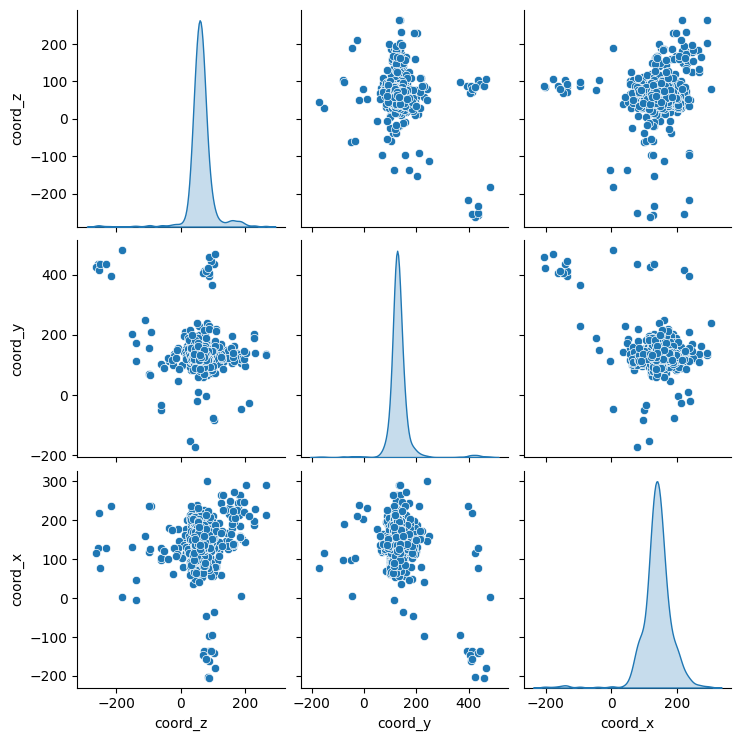

In [ ]:
sns.pairplot(master_df[['coord_z', 'coord_y', 'coord_x' ]], diag_kind='kde')

In [ ]:
#read all seriesUID from traindf and add them to masterdf if the same seriesUID is not present and aneurysm present for that seriesUID is 0 in masterdf and set default values for all other columsn
master_df = pd.merge(df_train,df_all_localization, how='left', on='SeriesInstanceUID')

In [66]:
neg_cases = df_train[(df_train['Aneurysm Present'] == 0) & (df_train['Modality'] == 'CTA')]
neg_cases

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
5,1.2.826.0.1.3680043.8.498.10014757658335054766...,53,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,1.2.826.0.1.3680043.8.498.10021411248005513321...,55,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
20,1.2.826.0.1.3680043.8.498.10048925006598672000...,82,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21,1.2.826.0.1.3680043.8.498.10052893794239333131...,55,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22,1.2.826.0.1.3680043.8.498.10057981374227560278...,68,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4381,1.2.826.0.1.3680043.8.498.99344977894147397154...,66,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4382,1.2.826.0.1.3680043.8.498.99348616762869189162...,72,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4390,1.2.826.0.1.3680043.8.498.99674090910456004499...,69,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4399,1.2.826.0.1.3680043.8.498.99895756899933461331...,39,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [70]:
master_df = pd.concat([master_df,neg_cases])
master_df

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,...,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present,coord_z,coord_y,coord_x
0,1.2.826.0.1.3680043.8.498.10035643165968342618...,62,Female,CTA,0,0,0,1,1,0,...,0,1,0,0,0,0,1,43.0,143.0,116.0
1,1.2.826.0.1.3680043.8.498.10035643165968342618...,62,Female,CTA,0,0,0,1,1,0,...,0,1,0,0,0,0,1,45.0,132.0,170.0
2,1.2.826.0.1.3680043.8.498.10035643165968342618...,62,Female,CTA,0,0,0,1,1,0,...,0,1,0,0,0,0,1,37.0,144.0,123.0
3,1.2.826.0.1.3680043.8.498.10077108087009955586...,55,Male,CTA,0,0,0,1,0,0,...,0,0,0,0,0,0,1,89.0,395.0,-137.0
4,1.2.826.0.1.3680043.8.498.10077108087009955586...,55,Male,CTA,0,0,0,1,0,0,...,0,0,0,0,0,0,1,88.0,407.0,-163.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4381,1.2.826.0.1.3680043.8.498.99344977894147397154...,66,Male,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4382,1.2.826.0.1.3680043.8.498.99348616762869189162...,72,Female,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4390,1.2.826.0.1.3680043.8.498.99674090910456004499...,69,Female,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4399,1.2.826.0.1.3680043.8.498.99895756899933461331...,39,Female,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [71]:
master_df[master_df['Aneurysm Present'] == 0]

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,...,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present,coord_z,coord_y,coord_x
5,1.2.826.0.1.3680043.8.498.10014757658335054766...,53,Female,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
6,1.2.826.0.1.3680043.8.498.10021411248005513321...,55,Female,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
20,1.2.826.0.1.3680043.8.498.10048925006598672000...,82,Female,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
21,1.2.826.0.1.3680043.8.498.10052893794239333131...,55,Female,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
22,1.2.826.0.1.3680043.8.498.10057981374227560278...,68,Female,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4381,1.2.826.0.1.3680043.8.498.99344977894147397154...,66,Male,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4382,1.2.826.0.1.3680043.8.498.99348616762869189162...,72,Female,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4390,1.2.826.0.1.3680043.8.498.99674090910456004499...,69,Female,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4399,1.2.826.0.1.3680043.8.498.99895756899933461331...,39,Female,CTA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
